<a href="https://colab.research.google.com/github/tsal4/data2000_labs/blob/main/exams/sp2026_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA-2000 Final Exam

In [1]:
!pip install ucimlrepo

## Grading Rubric

This final will be worth 15% of your total grade for this course. It will be graded out of 55 points, divided into 3 sections:

  - Data Prep & Feature Engineering: 5 points
    - 5 points will be awarded for the actual data cleaning (evaluating your Python code) and feature engineering (choice of engineered features, if any)
    - 5 points will be awarded for the text commentary narrating your choices and explaining your rationale for the data quality checks that you chose to use
    - *Note that Part 2 of this final (image classification) may not need much if any data prep.*
  - Model Building: 25 points
    - 5 points will be awarded by default, but may be subtracted from if there are substantial errors in your feature engineering that reduce the quality of your model
    - 4 points will be awarded for the actual model building (evaluating your Python code) for **each model** (8 points total)
    - 6 points will be awarded for the text commentary narrating your choices and explaining your rationale for **each model** (12 points total)
  - Model Validation/Evaluation: 25 points
    - 5 points will be awarded by default, but may be subtracted from if there are substantial errors in your model building that negatively impact the validity of your model
    - 4 points will be awarded for the actual model validation and evaluation (evaluating your Python code) for **each model** (8 points total)
    - 6 points will be awarded for the text commentary narrating your choices and explaining your rationale for **each model** (12 points total)

> **NOTE:** You will NOT be evaluated on whether you models actually make accurate predictions or not

### IMPORTANT:

In the rubric, I include points for a "text narrative" accompanying your code. To be clear, **I am asking for text/Markdown cells in this notebook, interspersed with your actual code, that discuss (in one or more paragraphs of prose English text) the choices that you make and their rationale**. I want these to appear alongside your code, and not as a single large summary at the end of the notebook. Likewise, code comments do not fulfill this requirement. The point here is for you to articulate, and for me to be able to understand, your thought process and the considerations that went into the modelling choices you made throughout this exam. Refer to the sample midterm solution on Github if you have questions about what I'm looking for, or ask me in class for additional clarification.

## Using Additional Resources

This is an open-resource exam. You may use any available resources as references. I will be available for any questions that you have during the exam.

Remember that all work must still be your own, and that this exam is governed by the Policy on Academic Honesty outlined in our course syllabus.

**If you make use of generative AI in the course of completing this exam, clearly note what work was your own original thought, what was produced by an LLM agent, and what was produced with the assistance of an LLM agent (but may not have been copied verbatim).**

## Part 1: Feed-Forward Neural Networks

For this exercise, we are going to use the [Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) from the UCI Machine Learning Repository.

This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in the Capital bikeshare system, along with corresponding weather and seasonal information. The goal of using this dataset is to build a predictive model capable of forecasting the number of bikes rented based on these environmental and seasonal features.

The target variable you are trying to predict is the count of bycicles rented (the column `cnt` in the dataset below)

In [2]:
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds
from ucimlrepo import fetch_ucirepo
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

### Load the Dataset

In [3]:
bike_sharing = fetch_ucirepo(id=275)
data = pd.concat(
    [
        bike_sharing.data.features,
        bike_sharing.data.targets
    ],
    axis=1
)

In [4]:
data.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB


In [6]:
train_df, test_df = train_test_split(data, test_size=0.2, random_state=26)

### Data Cleaning & Feature Engineering

**Variables being used: mnth, weekday, workingday, weathersit, temp, atemp, hum, windspeed**  
**I decided to use all of the weather variables because I think that will have the most impact on the 'cnt' label variable day-by-day. I wanted to still use some "calendar" variables like mnth and weekday, but not too many in order to keep the model simple.**

**There is no data cleaning to do with this dataset because there is no missing data and the normalization will be a part of the neural network.**

### Define the Model Architecture

**I started by defining the inputs of the variables I want to use.**

In [7]:
inputs = {
    'mnth':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.int64,
            name='mnth'),
    'weekday':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.int64,
            name='weekday'),
    'workingday':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.int64,
            name='workingday'),
    'weathersit':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.int64,
            name='weathersit'),
    'temp':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.float32,
            name='temp'),
    'atemp':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.float32,
            name='atemp'),
    'hum':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.float32,
            name='hum'),
    'windspeed':
        tf.keras.layers.Input(
            shape=(1,),
            dtype=tf.float32,
            name='windspeed')
}

**I normalize all of the float values.**

In [8]:
temp = tf.keras.layers.Normalization(
    name='normalization_temp',
    axis=None)
temp.adapt(np.array(train_df['temp']))
temp = temp(inputs.get('temp'))

atemp = tf.keras.layers.Normalization(
    name='normalization_atemp',
    axis=None)
atemp.adapt(np.array(train_df['atemp']))
atemp = atemp(inputs.get('atemp'))

hum = tf.keras.layers.Normalization(
    name='normalization_hum',
    axis=None)
hum.adapt(np.array(train_df['hum']))
hum = hum(inputs.get('hum'))

windspeed = tf.keras.layers.Normalization(
    name='normalization_windspeed',
    axis=None)
windspeed.adapt(np.array(train_df['windspeed']))
windspeed = windspeed(inputs.get('windspeed'))


train_cnt_normalized = tf.keras.layers.Normalization(axis=None)
train_cnt_normalized.adapt(
    np.array(train_df['cnt']))

test_cnt_normalized = tf.keras.layers.Normalization(axis=None)
test_cnt_normalized.adapt(
    np.array(test_df['cnt']))

**I embed all of the int64 values because they are technically categorical.**  
**I change the input dimension for each variable based on the amount of unique values that each variable has.**  
**The output dimension stays at 2 to keep things small and simple.**

In [9]:
mnth_encoded = tf.keras.layers.Embedding(
    input_dim=12,
    output_dim=2
)(inputs['mnth'])
mnth_encoded = tf.keras.layers.Flatten()(mnth_encoded)

weekday_encoded = tf.keras.layers.Embedding(
    input_dim=7,
    output_dim=2
)(inputs['weekday'])
weekday_encoded = tf.keras.layers.Flatten()(weekday_encoded)

workingday_encoded = tf.keras.layers.Embedding(
    input_dim=2,
    output_dim=2
)(inputs['workingday'])
workingday_encoded = tf.keras.layers.Flatten()(workingday_encoded)

weathersit_encoded = tf.keras.layers.Embedding(
    input_dim=4,
    output_dim=2
)(inputs['weathersit'])
weathersit_encoded = tf.keras.layers.Flatten()(weathersit_encoded)

**Then I concatenate the input layers into one tensor.**

In [10]:
preprocessing_layers = tf.keras.layers.Concatenate()(
    [mnth_encoded, weekday_encoded, workingday_encoded, weathersit_encoded, temp, atemp, hum, windspeed])

### Train the Model

In [11]:
def pandas_to_tfds(data: pd.DataFrame):
    features = data.drop(columns=['cnt'])
    labels = data['cnt']

    tf_data = tf.data.Dataset.from_tensor_slices((dict(features), labels))
    return tf_data

#### Example: Using `pandas_to_tfds` for Model Training

The above code cell provides a convenience function, `pandas_to_tfds()` to convert your Pandas dataframe into a dataset that Tensorflow will easily work with once it comes time to train your model. It has been set up to automatically separate your features from the target label (`cnt`) and return the `(features, label)` tuple format expected by Keras.

After you have your train/test splits of the data, you can use something like the example code below to feed your data into the model to train it.

```python
tf_train_data = pandas_to_tfds(train_data)
tf_val_data = pandas_to_tfds(test_data)

BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000

train_dataset = tf_train_data.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE)
val_dataset = tf_val_data.batch(BATCH_SIZE)

# You can use this to adapt a Normalization layer
# for a specific feature like 'temp'
temp_input = tf.keras.layers.Input(shape=(1,), name="temp")
temp_normalizer = tf.keras.layers.Normalization(axis=None)(temp_input)
temp_normalizer.adapt(train_dataset.map(lambda x, y: x['temp']))

model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)
```

**I start by creating the two hidden layers. I use 32 and 16 parameters to keep the model smaller and more simple.**  
**I feed those into a dense_output layer with 1 node so the model makes one prediction.**  

In [11]:
dense1 = tf.keras.layers.Dense(
    units=32,
    activation='relu',
    name='hidden_dense_layer_1')(preprocessing_layers)

dense2 = tf.keras.layers.Dense(
    units=16,
    activation='relu',
    name='hidden_dense_layer_2')(dense1)

dense_output = tf.keras.layers.Dense(
    units=1,
    name='dense_output')(dense2)

outputs = {
'dense_output': dense_output
}

In [12]:
learning_rate = 0.01
epochs = 15
batch_size = 1000
label_name = "cnt"

validation_split = 0.2

In [13]:
dnn_model = tf.keras.Model(inputs=inputs, outputs=outputs)
dnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanSquaredError()]
)
dnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mnth (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weekday             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ workingday          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weathersit          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 2)      │         24 │ mnth[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 2)      │         14 │ weekday[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 2)      │          4 │ workingday[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 2)      │          8 │ weathersit[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temp (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ atemp (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hum (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ windspeed           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_temp  │ (None, 1)         │          3 │ temp[0][0]        │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_atemp │ (None, 1)         │          3 │ atemp[0][0]       │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_hum   │ (None, 1)         │          3 │ hum[0][0]         │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,023 (4.01 KB)

 Trainable params: 1,011 (3.95 KB)

 Non-trainable params: 12 (64.00 B)

In [14]:
features = {name:np.array(value) for name, value in train_df.items()}
label = train_cnt_normalized(
    np.array(features.pop(label_name))
)

del features['dteday']

In [15]:
history = dnn_model.fit(
    x=features,
    y=label,
    batch_size=batch_size,
    epochs=epochs,
    shuffle=True,
    validation_split=validation_split)

# Get details that will be useful for plotting the loss curve.
epochs = history.epoch
hist = pd.DataFrame(history.history)
mse = hist["mean_squared_error"]

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'mnth': 'mnth', 'weekday': 'weekday', 'workingday': 'workingday', 'weathersit': 'weathersit', 'temp': 'temp', 'atemp': 'atemp', 'hum': 'hum', 'windspeed': 'windspeed'}
Received: inputs={'season': 'Tensor(shape=(None,))', 'yr': 'Tensor(shape=(None,))', 'mnth': 'Tensor(shape=(None,))', 'hr': 'Tensor(shape=(None,))', 'holiday': 'Tensor(shape=(None,))', 'weekday': 'Tensor(shape=(None,))', 'workingday': 'Tensor(shape=(None,))', 'weathersit': 'Tensor(shape=(None,))', 'temp': 'Tensor(shape=(None,))', 'atemp': 'Tensor(shape=(None,))', 'hum': 'Tensor(shape=(None,))', 'windspeed': 'Tensor(shape=(None,))'}
  warnings.warn(msg)


12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 299ms/step - loss: 0.7729 - mean_squared_error: 0.7729 - val_loss: 0.6170 - val_mean_squared_error: 0.6170
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5527 - mean_squared_error: 0.5527 - val_loss: 0.5048 - val_mean_squared_error: 0.5048
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5120 - mean_squared_error: 0.5120 - val_loss: 0.4912 - val_mean_squared_error: 0.4912
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4952 - mean_squared_error: 0.4952 - val_loss: 0.4836 - val_mean_squared_error: 0.4836
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4885 - mean_squared_error: 0.4885 - val_loss: 0.4781 - val_mean_squared_error: 0.4781
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4863 - mean_squared_error: 0.4863 - val_loss: 0.4777 - val_mean_squared_error: 0.4777
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4812 - mean_squared_error: 0.4812 - val_loss: 0.4737 - val_mean_squ

### Evaluate Model Performance

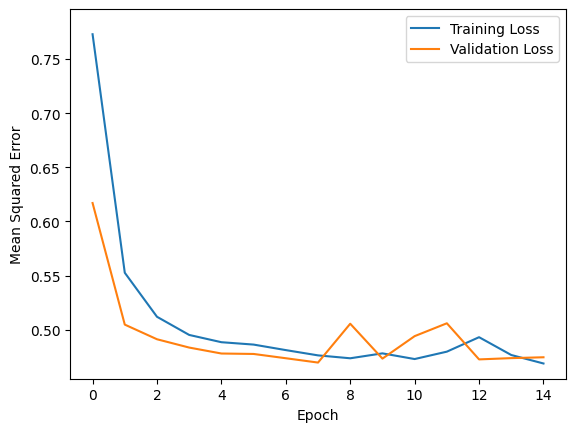

In [16]:
plt.figure()
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.plot(epochs, mse, label="Training Loss")
plt.plot(epochs, history.history["val_mean_squared_error"], label="Validation Loss")

merged_mse_lists = mse.tolist() + history.history["val_mean_squared_error"]
highest_loss = max(merged_mse_lists)
lowest_loss = min(merged_mse_lists)
top_of_y_axis = highest_loss * 1.03
bottom_of_y_axis = lowest_loss * 0.97

plt.ylim([bottom_of_y_axis, top_of_y_axis])
plt.legend()
plt.show()

**The model did show improvement as training went on, but a MSE of about .47 is terrible. This is because I normalized my cnt value, 0.5 is very high. The model did not perform well, and improving it may include adding more layers or more paramters because only about 1000 parameters is not a lot.**

In [17]:
test_features = {name:np.array(value) for name, value in test_df.items()}
test_label = test_cnt_normalized(np.array(test_features.pop(label_name)))
del test_features['dteday']

print("\n Evaluate the new model against the test set:")
dnn_model.evaluate(
    x=test_features,
    y=test_label,
    batch_size=batch_size,
    return_dict=True)


 Evaluate the new model against the test set:
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - loss: 0.4638 - mean_squared_error: 0.4638


{'loss': 0.46377962827682495, 'mean_squared_error': 0.46377962827682495}

**Also, in testing the model against the test set, the model still has a really bad MSE of about 0.46, making this a terrible model.**

## Part 2: Image Classification

For this exercise, we are going to use the [Horses or Humans](https://www.tensorflow.org/datasets/catalog/horses_or_humans) dataset to build an image classification model inspired by HBO's Silicon Valley's [Hotdog or Not Hotdog](https://www.youtube.com/watch?v=ACmydtFDTGs).

This dataset contains a large collection of CGI-generated images of horses and humans in various poses, backgrounds, and lighting conditions. The images are 300x300 pixels in 24-bit color.

In [18]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [19]:
#dont worry about train test split for this one

### Load the Dataset

In [20]:
ds_horses_humans, info_horses_humans = tfds.load(
    "horses_or_humans",
    split="train",
    with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/horses_or_humans/incomplete.GFX7D2_3.0.0/horses_or_humans-train.tfrecord*.…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/horses_or_humans/incomplete.GFX7D2_3.0.0/horses_or_humans-test.tfrecord*..…

Dataset horses_or_humans downloaded and prepared to /root/tensorflow_datasets/horses_or_humans/3.0.0. Subsequent calls will reuse this data.


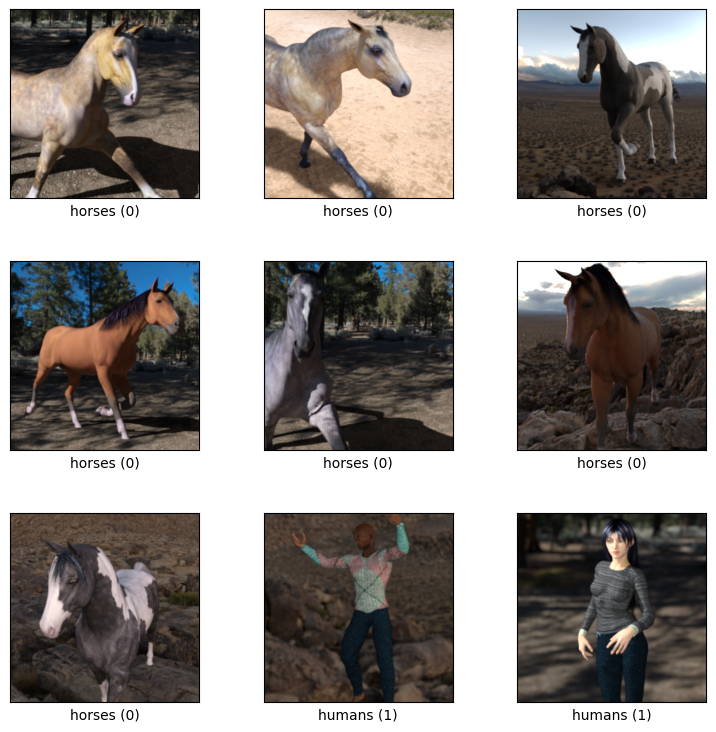

In [21]:
fig = tfds.show_examples(ds_horses_humans, info_horses_humans)
plt.show()

### Define the Model Architecture

In [22]:
img_input = tf.keras.layers.Input(shape = (300,300,3))

**Set the input too 300x300 and 3 channels.**

In [23]:
augmented_input = tf.keras.layers.RandomFlip("horizontal", input_shape=(300, 300, 3))(img_input)
augmented_input = tf.keras.layers.RandomRotation(0.1)(augmented_input)
augmented_input = tf.keras.layers.RandomZoom(0.1)(augmented_input)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**I chose to augment images using random flip, rotation, and zoom because of the small number of images in the dataset.**

In [24]:
conv1 = tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=4,
    activation="relu",
)(augmented_input)
conv1 = tf.keras.layers.AveragePooling2D(2)(conv1)

conv2 = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=4,
    activation="relu",
)(conv1)
conv2 = tf.keras.layers.AveragePooling2D(2)(conv2)

conv3 = tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=4,
    activation="relu",
)(conv2)
conv3 = tf.keras.layers.AveragePooling2D(2)(conv3)

**Now I feed the augmented images into the convolutional layers. I'm using three convolutional layers with increasing filters of 16, 32, and 64. This allows the model to capture more and more complex patterns in each layer.**

In [25]:
flattened = tf.keras.layers.Flatten()(conv2)
dropout = tf.keras.layers.Dropout(0.2)(flattened)

dense1 = tf.keras.layers.Dense(256, activation="relu")(dropout)
dense2 = tf.keras.layers.Dense(128, activation="relu")(dense1)

output = tf.keras.layers.Dense(2, activation="softmax")(dense2)

**I am using a small dropout layer of 20% because of the small dataset.**  
**I set the final output layer to 2 because there are only two options for classification: human and horse.**

In [26]:
model = tf.keras.Model(img_input, output)

In [27]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

**Using SparseCategoricalCrossentropy because I am classifying images.**

In [28]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 300, 300, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 297, 297, 16)   │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 148, 148, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 145, 145, 32)   │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 72, 72, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 165888)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 165888)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    42,467,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,509,746 (162.16 MB)

 Trainable params: 42,509,746 (162.16 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [29]:
#I was getting an error because the dataset is a dictionary with image label pairs. I used AI to generate this code to split the image from the label
ds_horses_humans_mapped = (
    ds_horses_humans
    .map(lambda x: (x['image'], x['label']))
    .batch(128)
)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    ds_horses_humans_mapped,
    batch_size=128,
    epochs=20,
    shuffle=True,
    callbacks=[early_stopping]
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 3328.2715 - sparse_categorical_accuracy: 0.5083
Epoch 2/20
3/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 2.4482 - sparse_categorical_accuracy: 0.6020

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,sparse_categorical_accuracy
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.7581 - sparse_categorical_accuracy: 0.6125
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.1660 - sparse_categorical_accuracy: 0.7001
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2988 - sparse_categorical_accuracy: 0.8637
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2911 - sparse_categorical_accuracy: 0.8773
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2153 - sparse_categorical_accuracy: 0.9094
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.5218 - sparse_categorical_accuracy: 0.8539
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1531 - sparse_categorical_accuracy: 0.9435
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2173 - sparse_categorical_accuracy: 0.9270
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1239 - sparse_categorical_accuracy: 0.9611
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.1145 - sparse_categorical_accura

### Evaluate Model Performance

<Figure size 640x480 with 0 Axes>

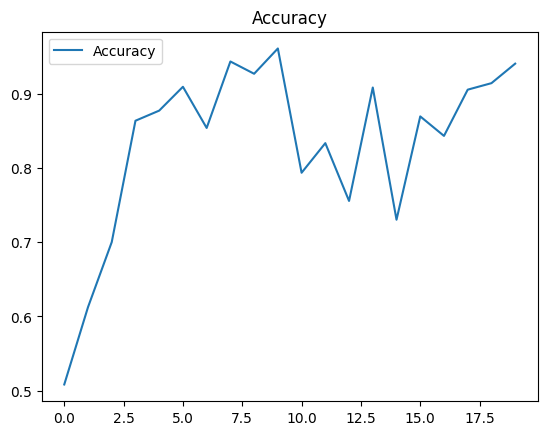

<Figure size 640x480 with 0 Axes>

In [31]:
acc = history.history['sparse_categorical_accuracy']

loss = history.history['loss']

epochs = range(len(acc))

plt.plot(epochs, acc, label='Accuracy')
plt.legend()
plt.title('Accuracy')

plt.figure()

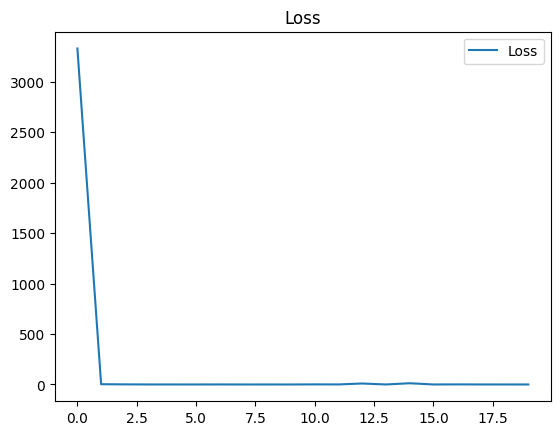

In [32]:
plt.plot(epochs, loss, label='Loss')
plt.legend()
plt.title('Loss')
plt.show()

**The model ends with an accuracy of over 90% so I would say this is a successful model, way more than the default of a 50-50 coin toss to predict either a human or a horse. However, around the 4th epoch the accurarcy goes all over the place, meaning the model could have stopped earlier. Also, I am unsure as to why the loss is starting off so high but it does drop off and stay low after the 2nd epoch which is good. Overall a successful model.**